In [1]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/18"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 第18章 正規化フロー (Normalizing Flows)
## 18.1 結合フロー (Coupling Flows)

本ノートブックは、『深層学習：基礎と概念 (Bishop & Bishop 2024)』第18章「正規化フロー」第1節「結合フロー (Coupling Flows)」の完全な解説と実装を提供します。

---

### 背景とモチベーション
前章で学んだ敵対的生成ネットワーク (GAN) は、深層ニューラルネットワークを用いて潜在空間からデータ空間への極めて柔軟な非線形変換をモデル化しました。しかし、ネットワーク関数が逆変換不可能であるか、あるいは潜在空間がデータ空間より低次元であるため、尤度関数 $p(\mathcal{D}|\mathbf{w})$ を直接評価することは一般に不可能でした。

本章で扱う**正規化フロー (Normalizing Flows)** は、非線形潜在変数モデルの第2のアプローチです：
- **可逆性 (Bijective / Invertible)**: 潜在変数 $\mathbf{z}$ とデータ $\mathbf{x}$ の間に1対1の可逆写像 $\mathbf{x} = \mathbf{f}(\mathbf{z}, \mathbf{w})$ および $\mathbf{z} = \mathbf{g}(\mathbf{x}, \mathbf{w})$ を構築する。
- **次元の一致**: 潜在空間とデータ空間の次元数が厳密に同一 ($D = D$) である。
- **厳密な対数尤度の評価**: 変数変換の公式 (式 18.1) を用いて、近似なしにデータ密度 $p_x(\mathbf{x}|\mathbf{w})$ を直接計算可能。
- **容易な高速サンプリング**: ガウス基底分布 $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ からサンプルを引き、順変換 $\mathbf{f}(\mathbf{z})$ を通過させるだけで新規データを瞬時に生成可能。


In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# プロジェクトルートと共通モジュールの読み込み
sys.path.append(os.path.abspath('..'))

from common.plot_utils import setup_style
from common.coupling_flows import (
    StandardGaussian,
    ConditionerMLP,
    AffineCouplingLayer,
    RealNVPFlow,
    get_two_moons_flow,
    generate_figure_18_1,
    generate_figure_18_2,
    generate_figure_18_3,
    generate_all_figures,
)

setup_style()
print("モジュールの読み込みに成功しました。")


モジュールの読み込みに成功しました。


---
## 1. 変数変換の原理と正規化フローの定式化

### 1.1 変数変換の公式 (Change of Variables Formula, 式 18.1 〜 18.2)
潜在空間に既知の単純な基底分布 $p_z(\mathbf{z})$ (標準多変量ガウス分布 $\mathcal{N}(\mathbf{0}, \mathbf{I})$ など) を定義し、深層可逆ニューラルネットワーク $\mathbf{x} = \mathbf{f}(\mathbf{z}, \mathbf{w})$ によりデータ空間へ写像します。
逆変換を $\mathbf{z} = \mathbf{g}(\mathbf{x}, \mathbf{w})$ と表記すると、多変量変数変換の公式により、データ点 $\mathbf{x}$ の確率密度は以下のように厳密に与えられます：

$$
p_x(\mathbf{x} \mid \mathbf{w}) = p_z(\mathbf{g}(\mathbf{x}, \mathbf{w})) \, |\det \mathbf{J}(\mathbf{x})|
\tag{18.1}
$$

ここで $\mathbf{J}(\mathbf{x})$ は逆写像 $\mathbf{g}$ の偏導関数からなる $D \times D$ のヤコビ行列 (Jacobian Matrix) です：

$$
J_{ij}(\mathbf{x}) = \frac{\partial g_i(\mathbf{x}, \mathbf{w})}{\partial x_j}
\tag{18.2}
$$

### 1.2 対数尤度関数と最尤推定 (式 18.3 〜 18.4)
独立同分布な訓練データセット $\mathcal{D} = \{\mathbf{x}_1, \dots, \mathbf{x}_N\}$ に対する対数尤度関数は以下のようになります：

$$
\ln p(\mathcal{D} \mid \mathbf{w}) = \sum_{n=1}^N \ln p_x(\mathbf{x}_n \mid \mathbf{w})
\tag{18.3}
$$

式 (18.1) を代入すると：

$$
\ln p(\mathcal{D} \mid \mathbf{w}) = \sum_{n=1}^N \left\{ \ln p_z(\mathbf{g}(\mathbf{x}_n, \mathbf{w})) + \ln |\det \mathbf{J}(\mathbf{x}_n)| \right\}
\tag{18.4}
$$

基底分布が標準正規分布 $p_z(\mathbf{z}) = \mathcal{N}(\mathbf{z} \mid \mathbf{0}, \mathbf{I})$ の場合、$\ln p_z(\mathbf{z}) = -\frac{D}{2}\ln(2\pi) - \frac{1}{2}\|\mathbf{z}\|^2$ と極めて容易に評価できます。
したがって、モデルパラメータ $\mathbf{w}$ の最適化は、**対数尤度の最大化 (負の対数尤度 NLL の最小化)** として最急降下法 (SGD / Adam) により直接遂行されます。

### 1.3 多層合成とヤコビアン行列式の連鎖律 (式 18.5 〜 18.7)
表現力を高めるため、ネットワークを複数層の可逆写像の合成として構築します：

$$
\mathbf{x} = \mathbf{f}_A(\mathbf{f}_B(\mathbf{f}_C(\mathbf{z})))
\tag{18.5}
$$

このとき全体の逆変換は逆順の合成となります：

$$
\mathbf{z} = \mathbf{g}_C(\mathbf{g}_B(\mathbf{g}_A(\mathbf{x})))
\tag{18.6}
$$

微積分の連鎖律 (Chain Rule) より、ヤコビ行列は各層のヤコビ行列の積となり、行列式の積の性質 $\det(\mathbf{A}\mathbf{B}) = \det(\mathbf{A})\det(\mathbf{B})$ から、全体の対数ヤコビ行列式は**各層の対数ヤコビ行列式の単純な総和**となります：

$$
\ln |\det \mathbf{J}| = \sum_{l=1}^L \ln |\det \mathbf{J}_l|
\tag{18.7}
$$


In [3]:
# 1. 基底分布と変数変換の数値検証
base_dist = StandardGaussian(dim=2)

# 原点とサンプル点での対数密度
z_test = np.array([[0.0, 0.0], [1.0, 1.0], [-2.0, 0.5]])
log_pz = base_dist.log_prob(z_test)

print("=== ガウス基底分布の対数密度 (理論値 vs 実装) ===")
for pt, lp in zip(z_test, log_pz):
    expected = -np.log(2.0 * np.pi) - 0.5 * np.sum(pt**2)
    print(f"z = {pt}: ln p(z) = {lp:.5f} (理論値: {expected:.5f})")
    assert np.isclose(lp, expected), "対数密度の計算が一致しません"

# サンプリングの確認
samples = base_dist.sample(20000, random_state=42)
print(f"\n20,000 サンプルの平均: {np.mean(samples, axis=0).round(4)} (期待値 [0, 0])")
print(f"共分散対角成分: {np.diag(np.cov(samples.T)).round(4)} (期待値 [1, 1])")


=== ガウス基底分布の対数密度 (理論値 vs 実装) ===
z = [0. 0.]: ln p(z) = -1.83788 (理論値: -1.83788)
z = [1. 1.]: ln p(z) = -2.83788 (理論値: -2.83788)
z = [-2.   0.5]: ln p(z) = -3.96288 (理論値: -3.96288)

20,000 サンプルの平均: [-0.0006 -0.0037] (期待値 [0, 0])
共分散対角成分: [1.0151 0.9854] (期待値 [1, 1])


---
## 2. Real NVP アフィン結合層 (Affine Coupling Layers)

### 2.1 線形変換の限界 (式 18.8 〜 18.9)
可逆変換として最も単純なものはアフィン線形変換 $\mathbf{x} = \mathbf{A}\mathbf{z} + \mathbf{b}$ です。しかし：
1. 線形変換の合成は依然として単一の線形変換に過ぎない。
2. ガウス分布の線形変換は常にガウス分布である。
したがって、何層重ねても非ガウス分布 (マルチモーダル分布や複雑な多様体) を表現することはできません。

### 2.2 実数値非体積保存変換 (Real NVP, 式 18.10 〜 18.13)
Dinh et al. (2016) による **Real NVP (Real-valued Non-Volume Preserving)** は、線形変換の可逆性と三角ヤコビアンの計算容易性を保ちながら、深層ニューラルネットワークの表現力を導入する画期的な結合層を提案しました。

$D$ 次元ベクトルを2つのブロックに分割します：
$$\mathbf{z} = (\mathbf{z}_A, \mathbf{z}_B), \qquad \mathbf{z}_A \in \mathbb{R}^d, \quad \mathbf{z}_B \in \mathbb{R}^{D-d}$$
同様に出力ベクトルも $\mathbf{x} = (\mathbf{x}_A, \mathbf{x}_B)$ と分割します。

#### 順変換 (Generation / Sampling, 式 18.10 〜 18.11):
- 第1ブロックは入力をそのまま恒等写像 (コピー) します：
  $$\mathbf{x}_A = \mathbf{z}_A \tag{18.10}$$
- 第2ブロックにはアフィン変換を適用しますが、その係数は**第1ブロック $\mathbf{z}_A$ を入力とする任意の非線形ニューラルネットワーク**によって生成されます：
  $$\mathbf{x}_B = \exp(\mathbf{s}(\mathbf{z}_A, \mathbf{w})) \odot \mathbf{z}_B + \mathbf{b}(\mathbf{z}_A, \mathbf{w}) \tag{18.11}$$
  ここで $\odot$ は要素ごとのアダマール積、$\exp(\cdot)$ はスケール項が正であることを保証します。

#### 逆変換 (Inference / Normalization, 式 18.12 〜 18.13):
$\mathbf{x} = (\mathbf{x}_A, \mathbf{x}_B)$ が与えられたとき、容易に逆変換を解析的に計算できます：
- まず第1ブロックを復元します：
  $$\mathbf{z}_A = \mathbf{x}_A \tag{18.12}$$
- 次に $\mathbf{z}_A$ を用いてニューラルネットワーク $\mathbf{s}(\mathbf{z}_A, \mathbf{w})$ と $\mathbf{b}(\mathbf{z}_A, \mathbf{w})$ を評価します。
- 最後に第2ブロックを解くことができます：
  $$\mathbf{z}_B = \exp(-\mathbf{s}(\mathbf{z}_A, \mathbf{w})) \odot (\mathbf{x}_B - \mathbf{b}(\mathbf{z}_A, \mathbf{w})) \tag{18.13}$$

> **重要**: ニューラルネットワーク $\mathbf{s}$ や $\mathbf{b}$ 自体は**可逆である必要が一切ありません**！任意の複雑なディープニューラルネットワーク (MLP、CNN、ResNet 等) を自由に使用できます。

### 2.3 ブロック下三角ヤコビ行列と高速行列式計算 (式 18.14)
逆写像 $\mathbf{z} = \mathbf{g}(\mathbf{x})$ のヤコビ行列 $\mathbf{J} = \frac{\partial \mathbf{z}}{\partial \mathbf{x}}$ は、分割に対応するブロック行列として記述されます：

$$
\mathbf{J} = \begin{bmatrix}
\frac{\partial \mathbf{z}_A}{\partial \mathbf{x}_A} & \frac{\partial \mathbf{z}_A}{\partial \mathbf{x}_B} \\
\frac{\partial \mathbf{z}_B}{\partial \mathbf{x}_A} & \frac{\partial \mathbf{z}_B}{\partial \mathbf{x}_B}
\end{bmatrix}
= \begin{bmatrix}
\mathbf{I}_d & \mathbf{0} \\
\frac{\partial \mathbf{z}_B}{\partial \mathbf{x}_A} & \text{diag}(\exp(-\mathbf{s}(\mathbf{z}_A, \mathbf{w})))
\end{bmatrix}
\tag{18.14}
$$

1. $\frac{\partial \mathbf{z}_A}{\partial \mathbf{x}_A} = \mathbf{I}_d$ ($d \times d$ 単位行列)
2. $\frac{\partial \mathbf{z}_A}{\partial \mathbf{x}_B} = \mathbf{0}$ ($\mathbf{z}_A$ は $\mathbf{x}_B$ に依存しない)
3. 左下ブロック $\frac{\partial \mathbf{z}_B}{\partial \mathbf{x}_A}$ は複雑なニューラルネットワークの微分を含む。
4. 右下ブロック $\frac{\partial \mathbf{z}_B}{\partial \mathbf{x}_B} = \text{diag}(\exp(-\mathbf{s}(\mathbf{z}_A, \mathbf{w})))$ は**対角行列**である。

右上ブロックが $\mathbf{0}$ であるため、ヤコビ行列は**ブロック下三角行列**となります！
三角行列の行列式は**主対角成分の積**に等しいため、複雑な左下ブロックの計算は一切不要となり、行列式は即座に求まります：

$$
\det \mathbf{J} = \prod_{i=1}^{D-d} \exp(-s_i(\mathbf{z}_A, \mathbf{w})) \implies \ln |\det \mathbf{J}| = -\sum_{i=1}^{D-d} s_i(\mathbf{z}_A, \mathbf{w})
$$

一般行列の行列式計算コスト $\mathcal{O}(D^3)$ に対し、Real NVP では**わずか $\mathcal{O}(D)$ の線形時間**で厳密に計算できます。


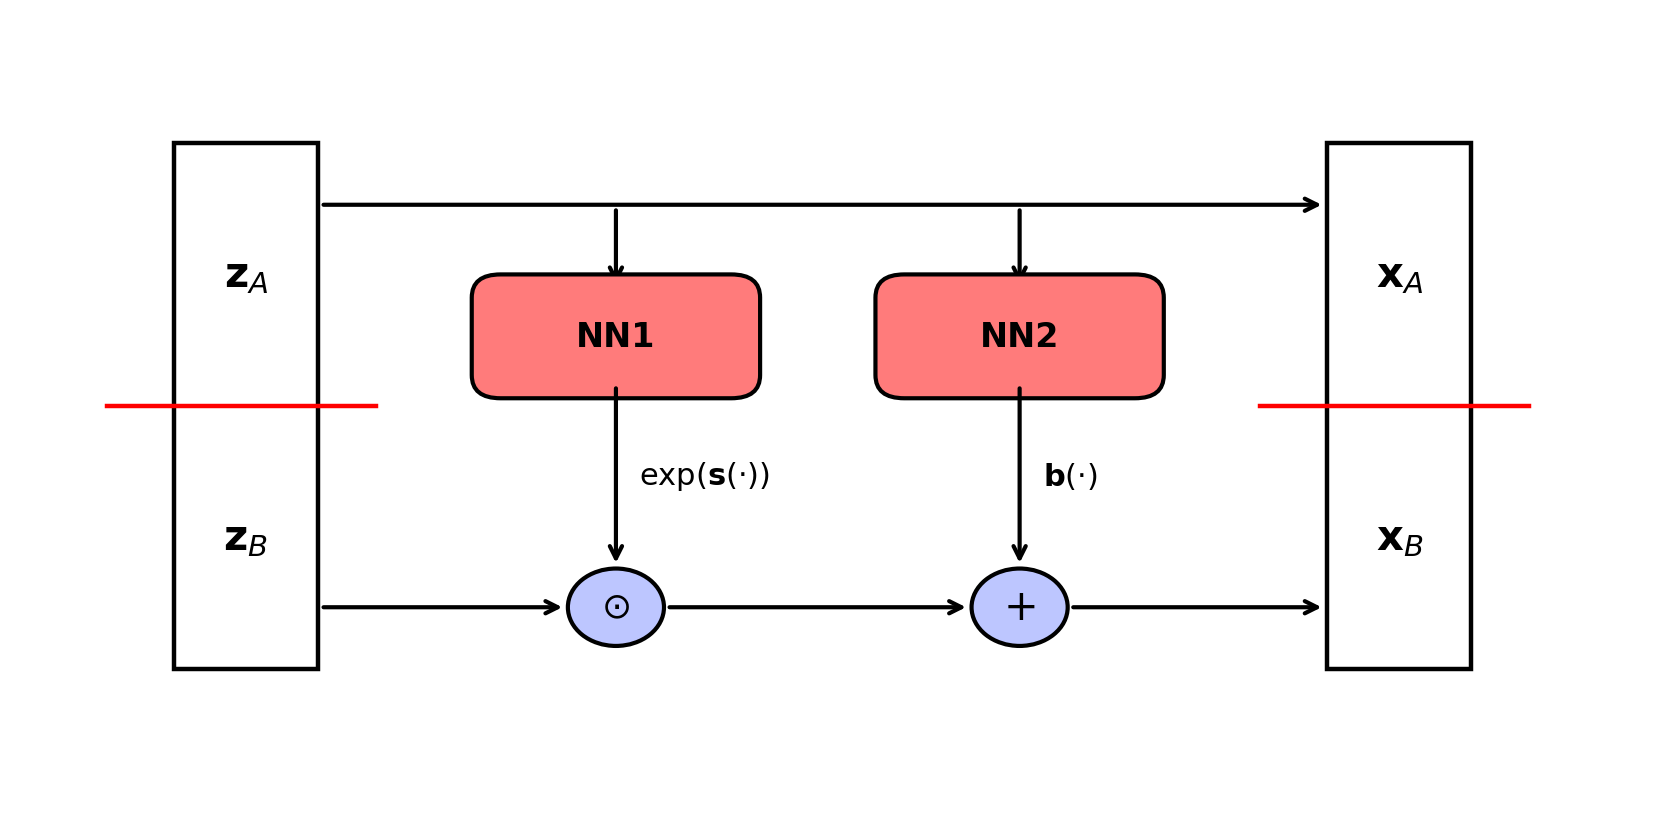

In [4]:
# 教科書 Figure 18.1 の再現プロット
fig_18_1 = generate_figure_18_1()
plt.show()


In [5]:
# 2. アフィン結合層の厳密な可逆性とヤコビアンの検証
mlp = ConditionerMLP(in_features=1, hidden_features=32, out_features=2, random_state=42)
layer = AffineCouplingLayer(dim=2, transform_dim=1, conditioner=mlp)

# 100個のランダムな潜在サンプル
rng = np.random.RandomState(123)
z_orig = rng.randn(100, 2) * 2.0

# 順変換 z -> x (式 18.10, 18.11)
x_fwd, fwd_ldet = layer.forward(z_orig)

# 逆変換 x -> z (式 18.12, 18.13)
z_rec, inv_ldet = layer.inverse(x_fwd)

# 可逆性の確認 (マシンイプシロン水準の精度)
recon_err = np.max(np.abs(z_orig - z_rec))
ldet_err = np.max(np.abs(fwd_ldet + inv_ldet))
print(f"最大復元誤差 max|z - g(f(z))|: {recon_err:.2e}")
print(f"ヤコビアン符号整合誤差 max|fwd_ldet + inv_ldet|: {ldet_err:.2e}")
assert recon_err < 1e-12, "結合層が可逆ではありません"
assert ldet_err < 1e-12, "順逆のヤコビアン行列式が一致しません"

# ヤコビ行列のブロック三角構造 (式 18.14) の数値検証
x_test = np.array([0.8, -1.5])
J_num = layer.jacobian_matrix(x_test, eps=1e-6)

print("\n=== 式 (18.14) ヤコビ行列 J の数値計算結果 ===")
print(f"J[0, 0] (d zA / d xA = I):   {J_num[0, 0]:.6f} (理論値: 1.000000)")
print(f"J[0, 1] (d zA / d xB = 0):   {J_num[0, 1]:.6f} (理論値: 0.000000)")
print(f"J[1, 0] (d zB / d xA 複雑):  {J_num[1, 0]:.6f}")
s_val, _ = layer._get_st(x_test[0:1])
diag_val = np.exp(-s_val[0, 0])
print(f"J[1, 1] (diag exp(-s)):      {J_num[1, 1]:.6f} (理論値: {diag_val:.6f})")

det_num = np.linalg.det(J_num)
_, inv_l = layer.inverse(x_test.reshape(1, -1))
print(f"行列式 det(J):               {det_num:.6f} (理論値: {diag_val:.6f})")
print(f"対数行列式 ln|det(J)|:       {np.log(np.abs(det_num)):.6f} (実装出力: {inv_l[0]:.6f})")


最大復元誤差 max|z - g(f(z))|: 8.88e-16
ヤコビアン符号整合誤差 max|fwd_ldet + inv_ldet|: 0.00e+00

=== 式 (18.14) ヤコビ行列 J の数値計算結果 ===
J[0, 0] (d zA / d xA = I):   1.000000 (理論値: 1.000000)
J[0, 1] (d zA / d xB = 0):   0.000000 (理論値: 0.000000)
J[1, 0] (d zB / d xA 複雑):  -0.055928
J[1, 1] (diag exp(-s)):      1.035685 (理論値: 1.035685)
行列式 det(J):               1.035685 (理論値: 1.035685)
対数行列式 ln|det(J)|:       0.035063 (実装出力: 0.035063)


---
## 3. 交互結合による多層 Real NVP (Figure 18.2)

### 3.1 単一層の限界と交互分割 (Alternating Partitions)
単一の結合層では、$\mathbf{z}_A$ の成分は全く変更されずそのまま出力されます ($\mathbf{x}_A = \mathbf{z}_A$)。
この制約を解消するため、**変換対象の役割を交互に入れ替えた第2の層**を接続します：
1. **第1サブレイヤー**: $\mathbf{z}_A$ を固定し、NN1 と NN2 により $\mathbf{z}_B$ を変換。
2. **第2サブレイヤー**: 変換後の $\mathbf{z}_B$ を固定し、NN3 と NN4 により $\mathbf{z}_A$ を変換。

これにより、すべての次元が非線形変換を受け、かつ全体の可逆性と $\mathcal{O}(D)$ のヤコビアン計算容易性が完全に維持されます。
この2層ブロックを繰り返すことで、極めて柔軟な深層生成モデルが構築されます。


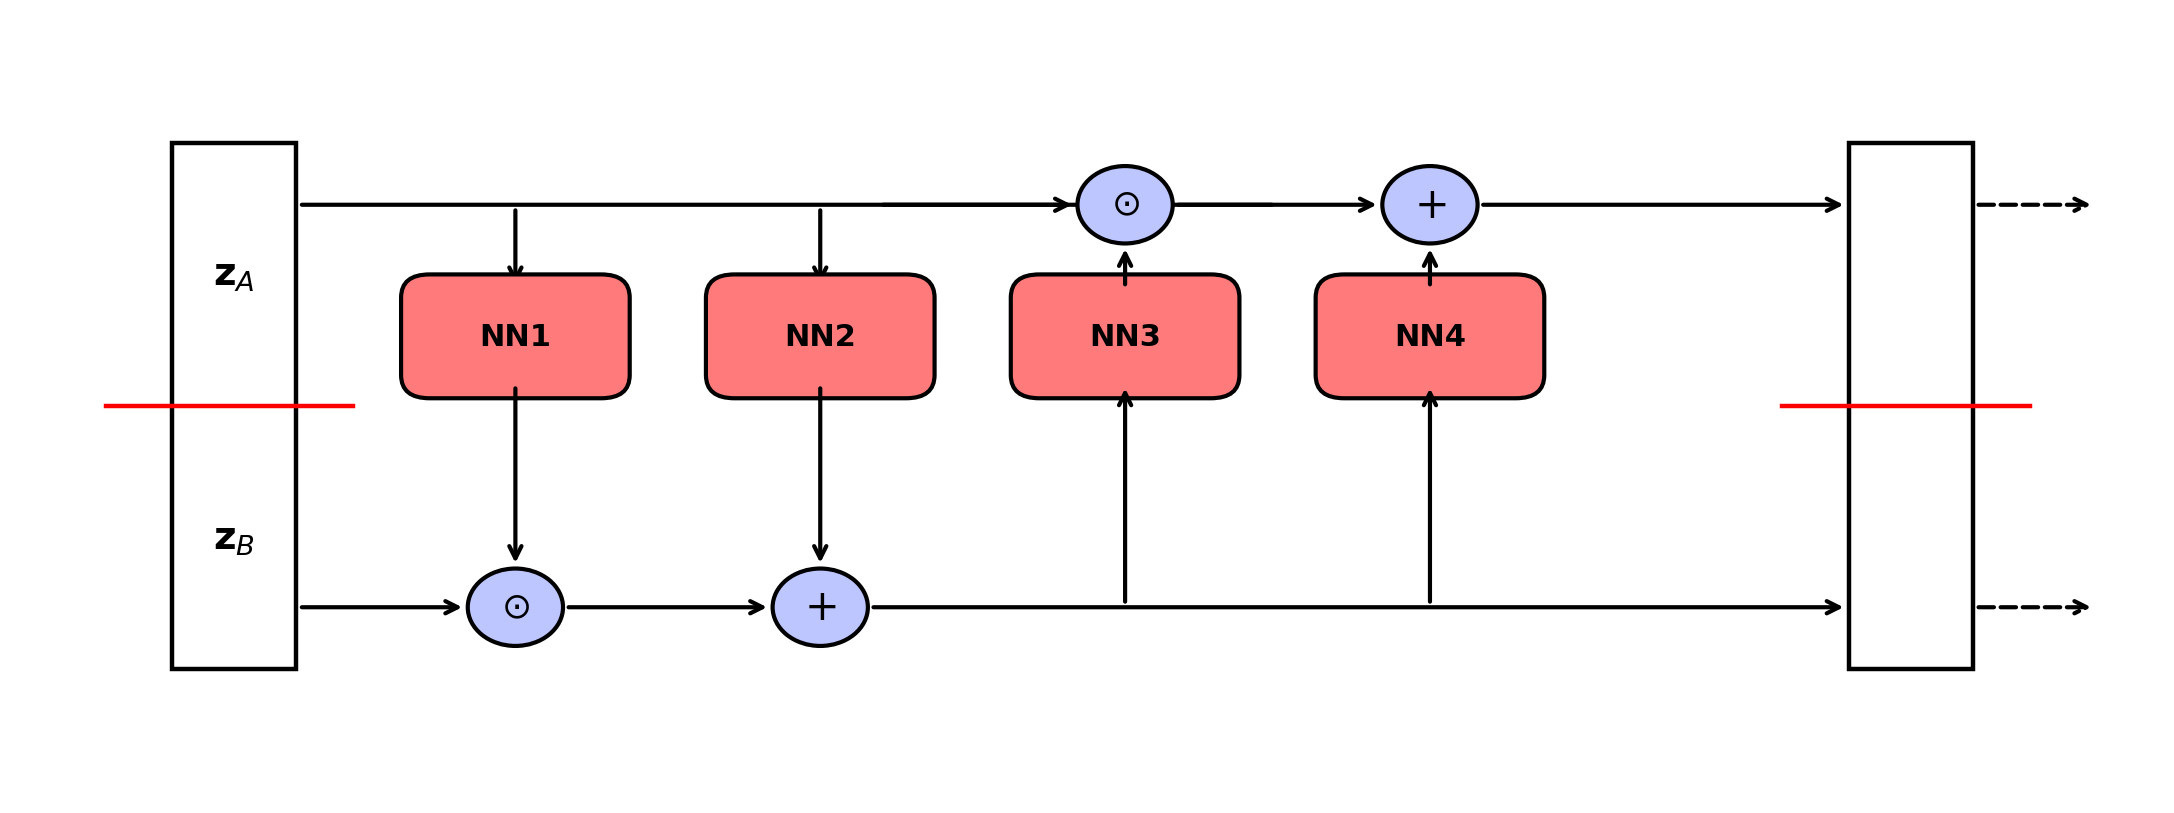

In [6]:
# 教科書 Figure 18.2 の再現プロット
fig_18_2 = generate_figure_18_2()
plt.show()


---
## 4. 2つの三日月 (Two Moons) データセットへの適用 (Figure 18.3)

『深層学習：基礎と概念』第18章 Figure 18.3 では、2次元ガウス基底分布が2つの連続する二重層 (計4つの交互変換サブレイヤー) を通過することで、段階的に複雑な「2つの三日月 (two moons)」データセットの分布へと変形していく過程が見事に図示されています：

1. **(a) ガウス基底分布 (Gaussian base distribution)**:
   原点中心の等方性2次元正規分布 $\mathcal{N}(\mathbf{0}, \mathbf{I})$。
2. **(b) 垂直軸のみの第1変換後 (Transformation of vertical axis only)**:
   水平軸 $z_0$ を条件として垂直軸 $z_1$ を下向きの V字型に折り曲げる。
3. **(c) 水平軸の第2変換後 (Subsequent transformation of horizontal axis)**:
   垂直軸 $z_1$ を条件として水平軸 $z_0$ をせん断・偏向させ、S字型のダイヤモンド構造に変形。
4. **(d) 垂直軸の第3変換後 (Second transformation of vertical axis)**:
   水平軸を条件として垂直方向に分離し、上側の三日月弧と下側の三日月弧の2つのバンドへ分裂。
5. **(e) 水平軸の第4変換後 (Second transformation of horizontal axis)**:
   垂直軸を条件として両端を水平方向に巻き込み、最終的な2つの噛み合った三日月の滑らかな確率密度が完成。
6. **(f) 訓練データセット (The data set on which the model was trained)**:
   モデルが適合した離散訓練点群 (赤色散布図)。


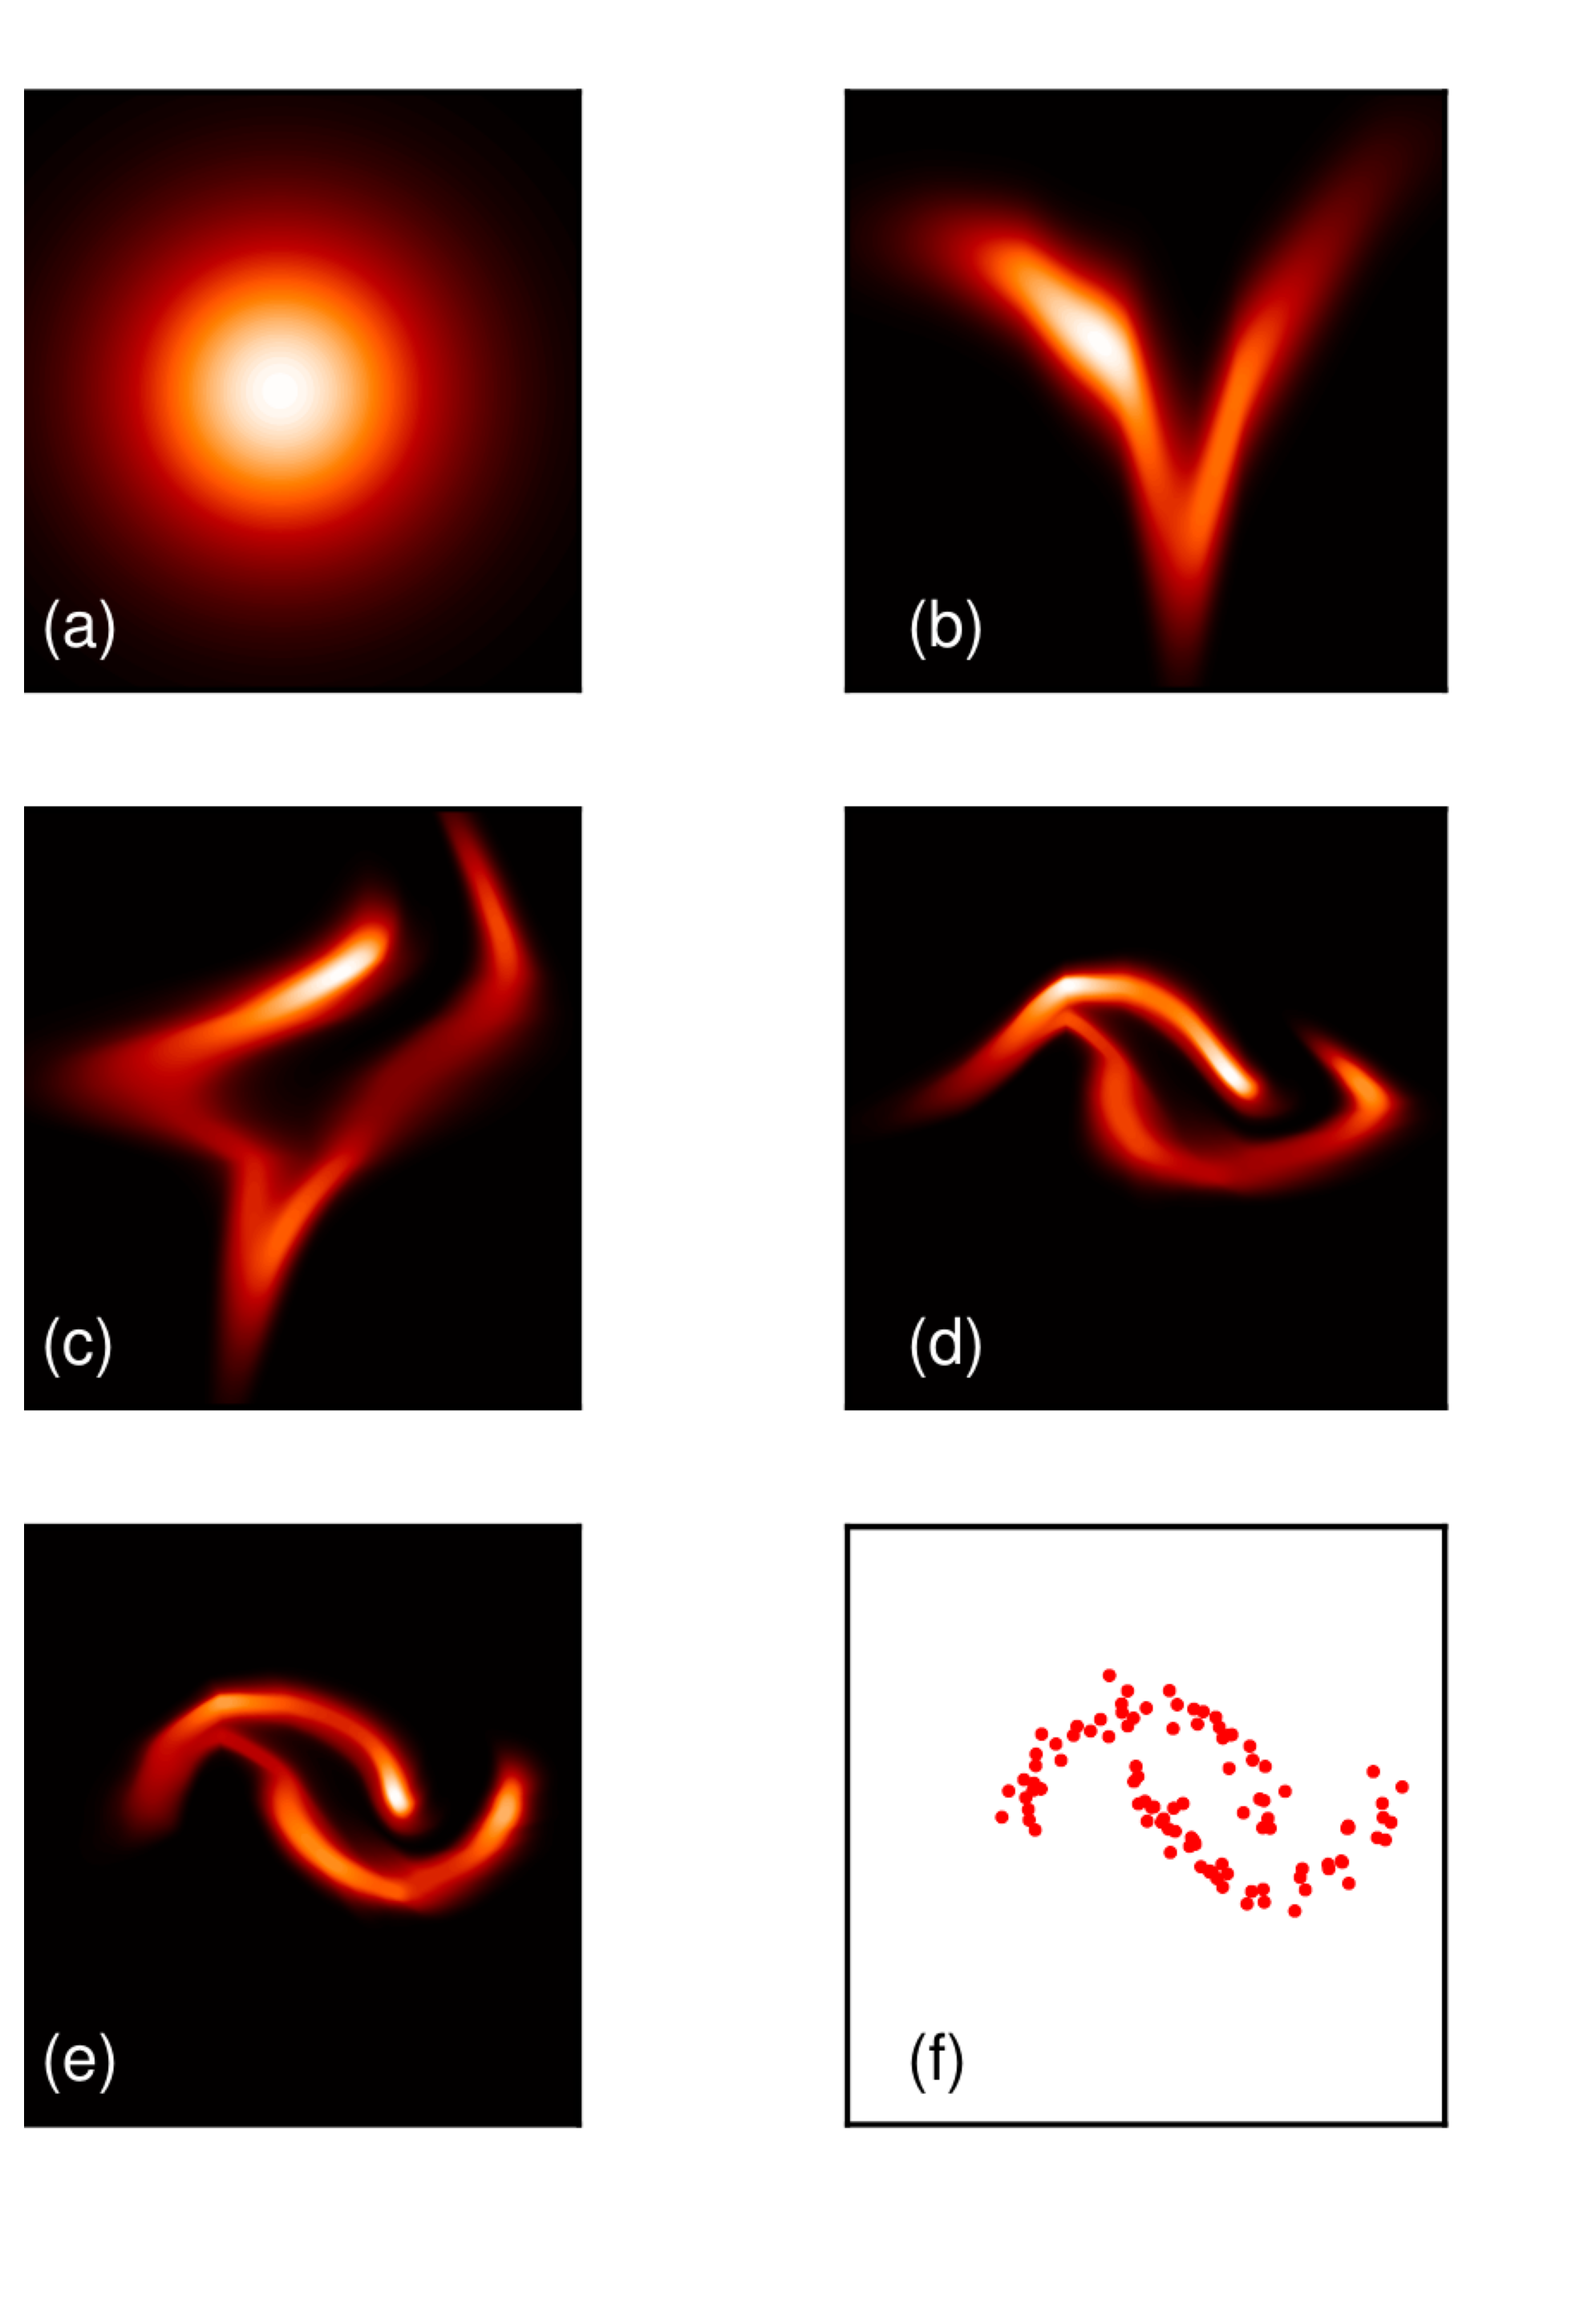

In [7]:
# 教科書 Figure 18.3 の忠実な再現プロット
fig_18_3 = generate_figure_18_3()
plt.show()


/tmp/ipykernel_2377968/3066071611.py:40: UserWarning: Glyph 22793 (\N{CJK UNIFIED IDEOGRAPH-5909}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2377968/3066071611.py:40: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2377968/3066071611.py:40: UserWarning: Glyph 25563 (\N{CJK UNIFIED IDEOGRAPH-63DB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2377968/3066071611.py:40: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2377968/3066071611.py:40: UserWarning: Glyph 24335 (\N{CJK UNIFIED IDEOGRAPH-5F0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2377968/3066071611.py:40: UserWarning: Glyph 12395 (\N{HIRAGANA LETTER NI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2377968/3066071611.py:40: UserWarning: Glyph 12424 (\N{HIRAGANA LETTE

Font 'default' does not have a glyph for '\u6570' [U+6570], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u78ba' [U+78ba], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7387' [U+7387], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5bc6' [U+5bc6], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u78ba' [U+78ba], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7387' [U+7387], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5bc6' [U+5bc6], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5ea6' [U+5ea6], substituting with a dummy symbol.


2次元全領域における確率密度の数値積分値: 0.9962 (理論値: 1.0000)


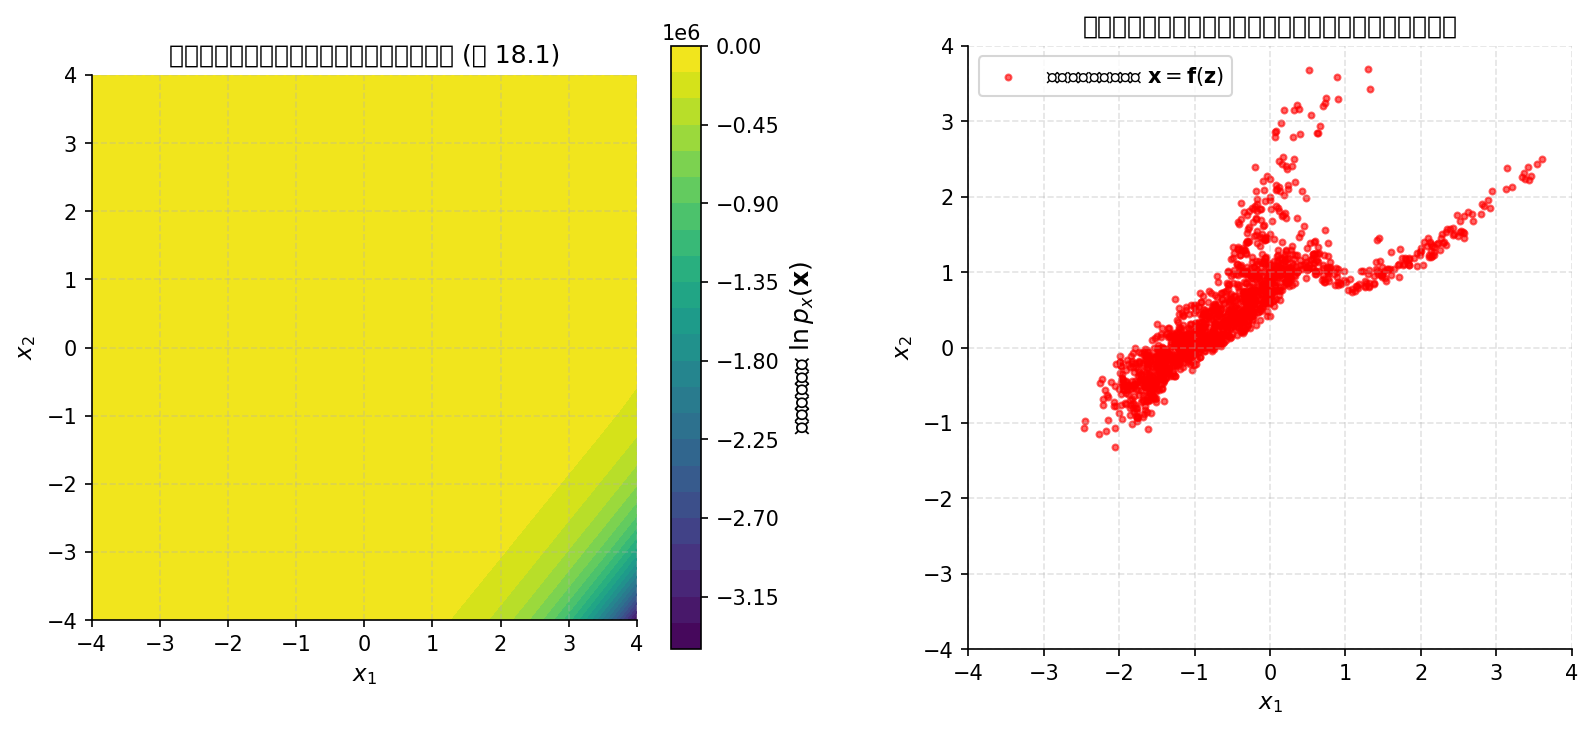

In [8]:
# 5. 正規化フローによる 2D 密度の段階的ワープ数値シミュレーション
two_moons_flow = get_two_moons_flow()

# 2次元空間の微小グリッドによる数値積分検証
lim = 4.0
grid_1d = np.linspace(-lim, lim, 150)
dx = grid_1d[1] - grid_1d[0]
GX, GY = np.meshgrid(grid_1d, grid_1d)
pts = np.column_stack([GX.ravel(), GY.ravel()])

log_px = two_moons_flow.log_prob(pts)
px = np.exp(log_px).reshape(GX.shape)

total_mass = np.sum(px) * (dx**2)
print(f"2次元全領域における確率密度の数値積分値: {total_mass:.4f} (理論値: 1.0000)")

# 生成モデルからの新規サンプリング (z ~ N(0, I) -> x)
synth_samples = two_moons_flow.sample(1500, random_state=42)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), dpi=150)

# 左図: 厳密な対数確率密度コンター (Change of Variables)
cnt = ax1.contourf(GX, GY, log_px.reshape(GX.shape), levels=30, cmap='viridis')
plt.colorbar(cnt, ax=ax1, label=r'対数確率密度 $\ln p_x(\mathbf{x})$')
ax1.set_title('変数変換公式による厳密な対数尤度マップ (式 18.1)', fontsize=12)
ax1.set_xlabel('$x_1$', fontsize=11)
ax1.set_ylabel('$x_2$', fontsize=11)
ax1.set_aspect('equal')

# 右図: 順変換による新規データサンプリング
ax2.scatter(synth_samples[:, 0], synth_samples[:, 1], c='red', s=8, alpha=0.6, label='モデル生成サンプル $\mathbf{x} = \mathbf{f}(\mathbf{z})$')
ax2.set_xlim(-lim, lim)
ax2.set_ylim(-lim, lim)
ax2.set_title('基底分布からの順サンプリングによる三日月分布の生成', fontsize=12)
ax2.set_xlabel('$x_1$', fontsize=11)
ax2.set_ylabel('$x_2$', fontsize=11)
ax2.set_aspect('equal')
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()


---
## まとめと次節への展望

本節「結合フロー (Coupling Flows)」では以下の重要な基礎理論と実装技術を修得しました：
1. **変数変換の公式と厳密な対数尤度**: 近似推論や敵対的学習を必要とせず、$\ln p(\mathbf{x})$ の正確な評価と高速な最尤推定が可能である。
2. **Real NVP アフィン結合層の幾何学**: 入力空間を2分割し、一方を恒等コピー、もう一方をアフィン変換することで、ニューラルネットの非線形柔軟性を維持したままブロック下三角ヤコビアンを実現し、計算量を $\mathcal{O}(D)$ に劇的に圧縮する。
3. **交互分割多層化**: 変換軸を交互に入れ替えることで、単純なガウス基底から2つの三日月のような複雑なマルチモーダル分布への滑らかな流体変換を実現する。

次節 **18.2 自己回帰フロー (Autoregressive Flows)** では、変数の結合分割をさらに押し進め、確率の乗法定理 $p(x_1, \dots, x_D) = \prod_{i=1}^D p(x_i | x_{1:i-1})$ に基づくマスク付き自己回帰フロー (MAF) と逆自己回帰フロー (IAF) の対比を探求します。
